In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns



df = pd.read_csv('insurance.csv')

In [3]:
# EDA
print("Shape\n")
print(df.shape)
print("Head\n")
print(df.head())
print("info\n")
print(df.info )#data type
print("Describe\n")
print(df.describe()) #gives numeric values and mean median 


# Null values
print("Null Values\n")
print(df.isnull().sum())

print(df.columns)


Shape

(1338, 7)
Head

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
info

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  

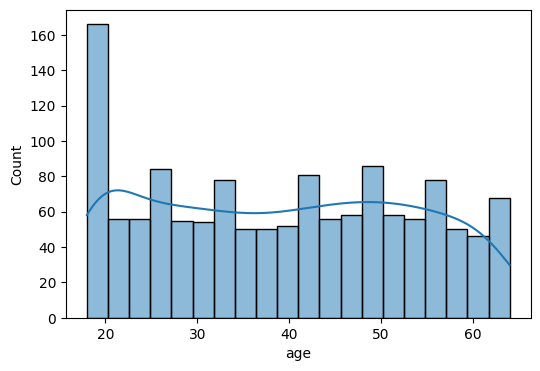

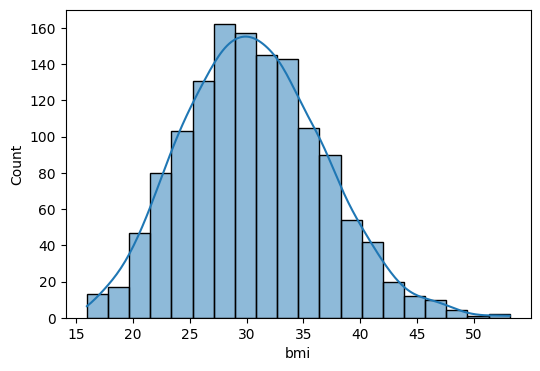

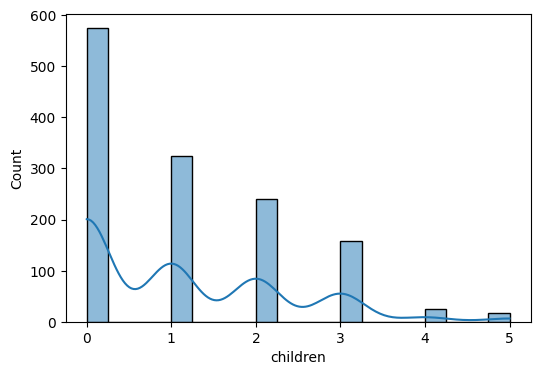

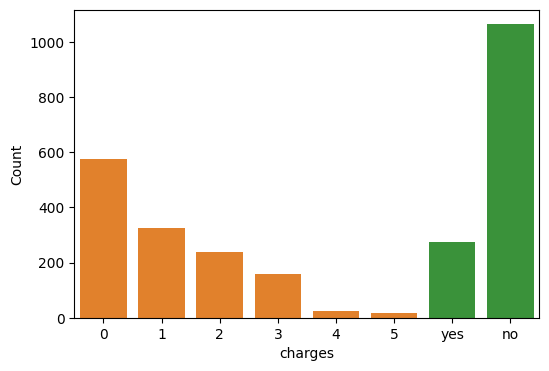

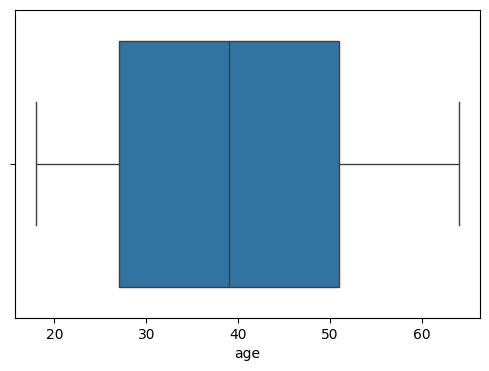

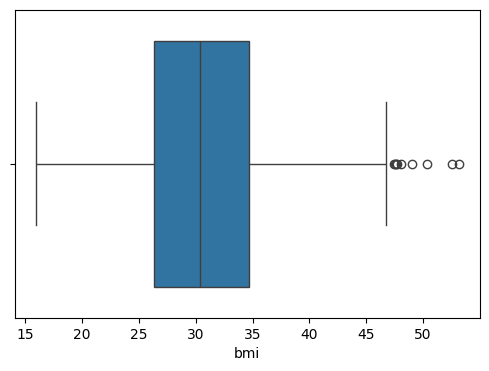

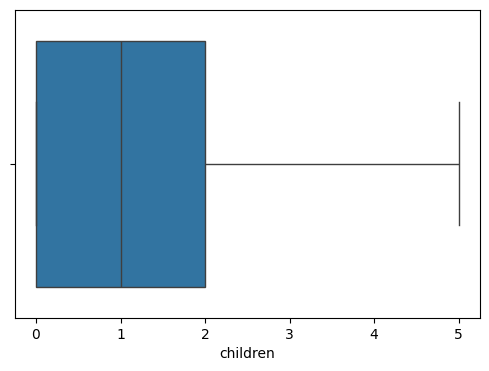

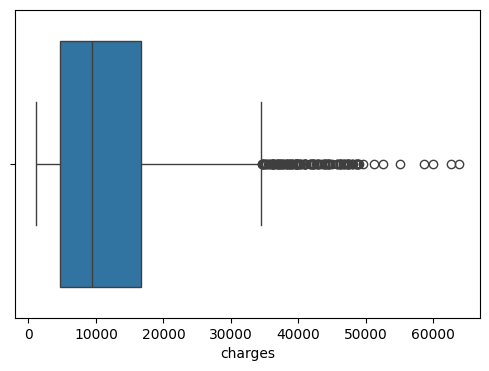

In [4]:
num_cols = ['age', 'bmi', 'children', 'charges']
for cols in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[cols],kde=True, bins=20)
    
    
# Col var
sns.countplot(x = df['children'])
sns.countplot(x = df['smoker'])

# Relations between col vars and identifying pattern bw insurance charges and smokers
for cols in num_cols:
    plt.figure(figsize= (6,4))
    sns.boxplot(x= df[cols])

Correlation betwen

<Axes: >

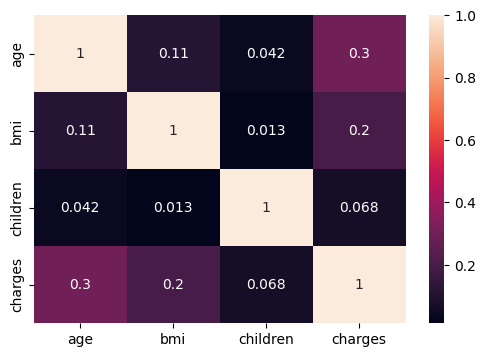

In [5]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True)   # this by default takes numeric values and finds relations

Data Cleaning and preprocessing

In [6]:
df_clean= df.copy()

df_clean.drop_duplicates(inplace=True) # Will drop duplicate row and replace the dataset not new copy

In [7]:
df_clean.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df_clean.dtypes 

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

We need all cols as Numeric

#Label Encoding Sex

In [9]:
df_clean['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [10]:

df_clean['sex']= df_clean['sex'].map({"male" : 0,"female": 1 })
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [11]:
df_clean['smoker'].value_counts() #Only yes and no confirmatn


smoker
no     1063
yes     274
Name: count, dtype: int64

In [12]:


df_clean['smoker']= df_clean['smoker'].map({"yes": 1, "no": 0})
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


Renaming Cols

In [13]:
df_clean.rename(columns = {
    'smoker':'is_smoker',
    'sex':'is_female'
},inplace=True)

df_clean.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


One Hot Encoding

In [14]:
df_clean= pd.get_dummies(df_clean,columns=['region'])
#,drop_first=True doest not let consider col name in values
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


Need to change true falst to numeric

In [15]:
df_clean = df_clean.astype(int)
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


Feature Engineering and Extraction

All your own research explore other methods and attribute

Since BMI is alwyas categorized in Underwight, Normal, Overweignt and obese for a range

In [16]:
df_clean['bmi_category'] = pd.cut(
    df_clean['bmi'],
    bins=[0,18.5,24.9,29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,Overweight
1,18,0,33,1,0,1725,0,0,1,0,Obese
2,28,0,33,3,0,4449,0,0,1,0,Obese
3,33,0,22,0,0,21984,0,1,0,0,Normal
4,32,0,28,0,0,3866,0,1,0,0,Overweight


Now One hot encode bmi category

In [17]:
df_clean= pd.get_dummies(df_clean,columns=['bmi_category'])
df_clean=df_clean.astype(int)
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0


In [18]:
df_clean=df_clean.rename(columns={'bmi_category_Normal': 'is_Normal'})
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,is_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0


Scaling the numeric columns (Scaling always after split)

In [19]:
from sklearn.preprocessing import StandardScaler
cols= ['age','bmi','children']
scaler = StandardScaler()
df_clean[cols]= scaler.fit_transform(df_clean[cols])
 

In [20]:
df_clean.head

<bound method NDFrame.head of            age  is_female  ...  bmi_category_Overweight  bmi_category_Obese
0    -1.440418          1  ...                        1                   0
1    -1.511647          0  ...                        0                   1
2    -0.799350          0  ...                        0                   1
3    -0.443201          0  ...                        0                   0
4    -0.514431          0  ...                        1                   0
...        ...        ...  ...                      ...                 ...
1333  0.767704          0  ...                        0                   1
1334 -1.511647          1  ...                        0                   1
1335 -1.511647          1  ...                        0                   1
1336 -1.297958          1  ...                        1                   0
1337  1.551231          1  ...                        1                   0

[1337 rows x 14 columns]>

Co-relations strength  
[Perarsons Correlatin]
Comparing values and determing their reations with target ie Y in our case charges

Values between -1 and 1
good if values less than -0.50 and greater 0.50  
Between .20 anf 0.50 is also good 
but values 0.10 and 0.20 shlud be considered on hit and trial

In [21]:
from scipy.stats import pearsonr
# List of cols to check against target
selected_features= {'age',  'is_female', 'bmi',  'children',  'is_smoker',
                'region_northeast', 'region_northwest',  'region_southeast',  'region_southwest',
                'bmi_category_Underweight',  'is_Normal',  'bmi_category_Overweight','bmi_category_Obese'}

correlations = {
    feature : pearsonr(df_clean[feature],df_clean['charges'])[0]
    for feature in selected_features
}
#adding output ot dataframe
correlation_df= pd.DataFrame(list(correlations.items()),columns=['feature', 'Pearsons Corr Value'])
correlation_df.sort_values(by='Pearsons Corr Value',ascending=False)

,feature,Pearsons Corr Value
5,is_smoker,0.787234
11,age,0.298309
12,bmi_category_Obese,0.200348
3,bmi,0.196236
4,region_southeast,0.073577
1,children,0.067390
9,region_northeast,0.005946
2,region_northwest,-0.038695
6,region_southwest,-0.043637
0,bmi_category_Underweight,-0.050599


Reoving northwest, southwest

Chi Sq test comparing cat variables with each other evn with y


In [22]:
cat_features= {'is_female', 'is_smoker',
                'region_northeast', 'region_northwest',  'region_southeast',  'region_southwest',
                'bmi_category_Underweight',  'is_Normal',  'bmi_category_Overweight','bmi_category_Obese'}

Need to create a bin for charges as it is not categorical

In [23]:
df_clean['charges_bin']= pd.qcut(df_clean['charges'],q=4,labels=False)

In [24]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05
chi2_results={}

for col in cat_features:
    contingency = pd.crosstab(df_clean[col], df_clean['charges_bin'])
    chi2_stat, p_val,_,_ = chi2_contingency(contingency)
    decision = 'Reject Null Hypo(Keep Feature)' if p_val<alpha else 'Accept Null hypo (Remove feature)'
    chi2_results[col] = {
        'chi2_statistics': chi2_stat,
        'p_value': p_val,
        'decision': decision 
    }

    chi2_df = pd.DataFrame(chi2_results).T #T is transpose ie col becomes row and row becoms col
    chi2_df= chi2_df.sort_values(by='p_value')
    print(chi2_df)

                         chi2_statistics  ...                           decision
bmi_category_Underweight         3.37403  ...  Accept Null hypo (Remove feature)

[1 rows x 3 columns]
                         chi2_statistics  ...                           decision
bmi_category_Underweight         3.37403  ...  Accept Null hypo (Remove feature)
region_northwest                 1.13424  ...  Accept Null hypo (Remove feature)

[2 rows x 3 columns]
                         chi2_statistics  ...                           decision
region_southeast               15.998167  ...     Reject Null Hypo(Keep Feature)
bmi_category_Underweight         3.37403  ...  Accept Null hypo (Remove feature)
region_northwest                 1.13424  ...  Accept Null hypo (Remove feature)

[3 rows x 3 columns]
                         chi2_statistics  ...                           decision
is_smoker                     848.219178  ...     Reject Null Hypo(Keep Feature)
region_southeast               15.998167  .

Remove fearurs based on both tests

In [25]:
final_df = df_clean[['age',  'is_female', 'bmi',  'children',  'is_smoker',
                     'charges',  'region_southeast','bmi_category_Obese']]
final_df.head()

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0


Training   

In [ ]:
from sklearn.model_selection import train_test_split

X = final_df.drop('charges',axis=1)
y = final_df['charges']

X_train, X_temp, y_train, y_temp = train_test_split(X, y,train_size=0.6, random_state=1)
X_test,X_val,y_test,y_val = train_test_split(X_temp,y_temp,test_size=0.5,random_state=1)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, Y_train)

c:\Users\Vikrant\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'
